In [ ]:
!pip install pmdarima kagglehub pandas numpy matplotlib seaborn statsmodels scikit-learn requests tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import os
import warnings
from datetime import datetime, timedelta
from tqdm.auto import tqdm

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

CONFIG = {
    'coins': [
        'BTC-USD', 'ETH-USD', 'XRP-USD', 'BNB-USD', 'SOL-USD',
        'TRX-USD', 'DOGE-USD', 'ADA-USD', 'HYPE-USD', 'BCH-USD',
        'LINK-USD', 'LEO-USD', 'ZEC-USD', 'XLM-USD', 'XMR-USD',
        'LTC-USD', 'HBAR-USD', 'AVAX-USD', 'SUI-USD', 'SHIB-USD'
    ],
    'horizons': [1, 7],
    'train_days': 730,
    'test_days': 365,
    'use_rolling': True,
    'refit_every': 30,
    'output_dir': '/content/arimax_output/'
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Config: {len(CONFIG['coins'])} coins, horizons={CONFIG['horizons']}")


Config: 20 coins, horizons=[1, 7]


In [ ]:
def get_fear_greed():
    """
    Fetch historical Fear & Greed Index from Alternative.me
    API docs: https://alternative.me/crypto/fear-and-greed-index/
    """
    url = "https://api.alternative.me/fng/"
    params = {
        'limit': 0,
        'format': 'json'
    }

    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if 'data' not in data:
            print("No data in response")
            return None

        records = data['data']
        df = pd.DataFrame(records)

        df['date'] = pd.to_datetime(df['timestamp'].astype(int), unit='s')
        df['fng'] = df['value'].astype(int)
        df['fng_class'] = df['value_classification']

        df = df[['date', 'fng', 'fng_class']]
        df = df.sort_values('date').reset_index(drop=True)

        print(f"Fear & Greed: {len(df)} days ({df['date'].min().date()} to {df['date'].max().date()})")
        return df

    except Exception as e:
        print(f"Error fetching Fear & Greed: {e}")
        return None

fng_data = get_fear_greed()

Fear & Greed: 2857 days (2018-02-01 to 2025-12-01)


In [ ]:
import kagglehub
import glob

path = kagglehub.dataset_download("isaaclopgu/cryptocurrency-historical-prices-top-100-2025")
csv_files = glob.glob(f"{path}/*.csv") + glob.glob(f"{path}/**/*.csv", recursive=True)
DATA_PATH = csv_files[0]
print(f"Price data: {DATA_PATH}")

100%|██████████| 12.7M/12.7M [00:00<00:00, 64.2MB/s]

Extracting files...


Price data: /root/.cache/kagglehub/datasets/isaaclopgu/cryptocurrency-historical-prices-top-100-2025/versions/84/Crypto_historical_data.csv


In [ ]:
def clean_and_build_features(filepath, fng_df):
    """Load price data and create all features"""

    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
    df['Date'] = pd.to_datetime(df['Date'].dt.date)

    df = df[df['ticker'].isin(CONFIG['coins'])].copy()

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Open', 'High', 'Low', 'Close'])

    df['High'] = df[['Open', 'High', 'Low', 'Close']].max(axis=1)
    df['Low'] = df[['Open', 'High', 'Low', 'Close']].min(axis=1)

    df = df.sort_values(['ticker', 'Date', 'Volume'], ascending=[True, True, False])
    df = df.drop_duplicates(subset=['ticker', 'Date'], keep='first')

    df['PriceRange'] = df['High'] - df['Low']
    df['LogRange'] = np.log(df['PriceRange'].replace(0, np.nan))

    df = df.sort_values(['ticker', 'Date']).reset_index(drop=True)

    # Volume features
    df['vol_pct_change'] = df.groupby('ticker')['Volume'].pct_change()
    df['vol_ma7'] = df.groupby('ticker')['Volume'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['vol_ratio'] = df['Volume'] / df['vol_ma7']
    df['vol_spike'] = (df['vol_ratio'] > 2).astype(int)

    # Price momentum features
    df['return_1d'] = df.groupby('ticker')['Close'].pct_change()
    df['return_7d'] = df.groupby('ticker')['Close'].pct_change(7)
    df['range_ma7'] = df.groupby('ticker')['PriceRange'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df['range_ratio'] = df['PriceRange'] / df['range_ma7']

    # BTC as market leader (affects all altcoins)
    btc = df[df['ticker'] == 'BTC-USD'][['Date', 'Close', 'PriceRange']].copy()
    btc.columns = ['Date', 'btc_close', 'btc_range']
    btc['btc_return_1d'] = btc['btc_close'].pct_change()
    btc['btc_return_7d'] = btc['btc_close'].pct_change(7)
    btc['btc_range_ma7'] = btc['btc_range'].rolling(7, min_periods=1).mean()
    btc['btc_range_ratio'] = btc['btc_range'] / btc['btc_range_ma7']

    df = df.merge(btc[['Date', 'btc_return_1d', 'btc_return_7d', 'btc_range_ratio']], on='Date', how='left')

    # BTC's share of total volume
    daily_vol = df.groupby('Date')['Volume'].sum().reset_index()
    daily_vol.columns = ['Date', 'total_vol']
    df = df.merge(daily_vol, on='Date', how='left')

    btc_vol = df[df['ticker'] == 'BTC-USD'][['Date', 'Volume']].copy()
    btc_vol.columns = ['Date', 'btc_vol']
    df = df.merge(btc_vol, on='Date', how='left')
    df['btc_dominance'] = df['btc_vol'] / df['total_vol']
    df['btc_dominance'] = df['btc_dominance'].fillna(0.5)

    df = df.drop(columns=['total_vol', 'btc_vol'], errors='ignore')

    # Fear & Greed features
    if fng_df is not None:
        fng = fng_df.copy()
        fng = fng.rename(columns={'date': 'Date'})
        df = df.merge(fng[['Date', 'fng']], on='Date', how='left')

        df['fng'] = df['fng'].fillna(method='ffill').fillna(50)

        df['fng_ma7'] = df.groupby('ticker')['fng'].transform(lambda x: x.rolling(7, min_periods=1).mean())
        df['fng_change_7d'] = df.groupby('ticker')['fng'].diff(7)
        df['fng_extreme_fear'] = (df['fng'] < 25).astype(int)
        df['fng_extreme_greed'] = (df['fng'] > 75).astype(int)
    else:
        df['fng'] = 50
        df['fng_ma7'] = 50
        df['fng_change_7d'] = 0
        df['fng_extreme_fear'] = 0
        df['fng_extreme_greed'] = 0

    # Day of week
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Clean up infinities
    df = df.replace([np.inf, -np.inf], np.nan)

    print(f"\nFeatures built:")
    print(f"  Volume: vol_ratio, vol_spike")
    print(f"  Momentum: return_1d, return_7d, range_ratio")
    print(f"  BTC leader: btc_return_1d, btc_return_7d, btc_range_ratio, btc_dominance")
    print(f"  Sentiment: fng, fng_ma7, fng_change_7d, fng_extreme_fear, fng_extreme_greed")
    print(f"  Calendar: is_weekend")
    print(f"\nShape: {df.shape}")

    return df

df = clean_and_build_features(DATA_PATH, fng_data)
df.to_csv(f"{CONFIG['output_dir']}arimax_features.csv", index=False)



Features built:
  Volume: vol_ratio, vol_spike
  Momentum: return_1d, return_7d, range_ratio
  BTC leader: btc_return_1d, btc_return_7d, btc_range_ratio, btc_dominance
  Sentiment: fng, fng_ma7, fng_change_7d, fng_extreme_fear, fng_extreme_greed
  Calendar: is_weekend

Shape: (52970, 29)


In [ ]:
# All features will be lagged by 1 day in the model to prevent leakage
FEATURES = [
    'vol_ratio',
    'vol_spike',

    'return_1d',
    'return_7d',
    'range_ratio',

    'btc_return_1d',
    'btc_return_7d',
    'btc_range_ratio',
    'btc_dominance',

    'fng',
    'fng_ma7',
    'fng_extreme_fear',
    'fng_extreme_greed',

    'is_weekend'
]

print(f"Using {len(FEATURES)} exogenous features")


Using 14 exogenous features


In [ ]:
class CryptoARIMAX:
    def __init__(self, config, features):
        self.config = config
        self.features = features

    def prepare_coin_data(self, df, ticker):
        """Get data for one coin with features lagged by 1 day"""
        coin = df[df['ticker'] == ticker].copy()
        coin = coin.sort_values('Date').reset_index(drop=True)

        # Lag all features to prevent look-ahead bias
        for col in self.features:
            if col in coin.columns:
                coin[f'{col}_lag1'] = coin[col].shift(1)

        coin = coin.iloc[1:].reset_index(drop=True)
        return coin

    def get_lagged_feature_names(self):
        return [f'{col}_lag1' for col in self.features]

    def find_best_order(self, y, X):
        """Find optimal ARIMA order with exogenous variables"""
        try:
            model = auto_arima(
                y, exogenous=X,
                start_p=0, max_p=5,
                start_q=0, max_q=5,
                d=None, max_d=2,
                seasonal=False,
                stepwise=True,
                suppress_warnings=True,
                error_action='ignore',
                information_criterion='bic'
            )
            return model.order
        except:
            return (1, 1, 1)

    def run_walkforward(self, df, ticker):
        """Walk-forward validation"""
        coin = self.prepare_coin_data(df, ticker)
        feature_cols = self.get_lagged_feature_names()

        n = len(coin)
        train_size = self.config['train_days']
        test_size = min(self.config['test_days'], n - train_size)

        if test_size < 30:
            print(f"  {ticker}: insufficient data ({n} days, need {train_size + 30})")
            return None

        test_start = n - test_size
        test_end = n

        print(f"  {ticker}: {n} days total, testing idx {test_start}-{test_end}")

        init_data = coin.iloc[:test_start]
        y_init = init_data['LogRange'].dropna()
        X_init = init_data.loc[y_init.index, feature_cols].fillna(0)

        order = self.find_best_order(y_init.tail(365), X_init.tail(365))
        print(f"    Order: {order}")

        results = {h: [] for h in self.config['horizons']}
        refit_counter = 0

        for i in tqdm(range(test_start, test_end), desc=f"    {ticker}", leave=False):
            refit_counter += 1

            # training window
            if self.config['use_rolling']:
                start_idx = max(0, i - train_size)
            else:
                start_idx = 0

            train = coin.iloc[start_idx:i]
            y_train = train['LogRange'].dropna()

            if len(y_train) < 50:
                continue

            X_train = train.loc[y_train.index, feature_cols].fillna(0)

            if refit_counter >= self.config['refit_every']:
                order = self.find_best_order(y_train.tail(365), X_train.tail(365))
                refit_counter = 0

            try:
                model = ARIMA(y_train, exog=X_train, order=order)
                fit = model.fit()
                residuals = fit.resid.values
            except:
                continue

            for h in self.config['horizons']:
                target_idx = i + h - 1
                if target_idx >= n:
                    continue

                actual = coin.iloc[target_idx]['LogRange']
                actual_raw = coin.iloc[target_idx]['PriceRange']
                target_date = coin.iloc[target_idx]['Date']

                X_future = coin.iloc[i-1:i][feature_cols].fillna(0).values
                if h > 1:
                    X_future = np.tile(X_future, (h, 1))

                try:
                    fc = fit.get_forecast(steps=h, exog=X_future)
                    pred = fc.predicted_mean.iloc[-1]

                    std = np.std(residuals[np.isfinite(residuals)]) * np.sqrt(h)

                    results[h].append({
                        'date': target_date,
                        'actual': actual,
                        'actual_raw': actual_raw,
                        'predicted': pred,
                        'lower_80': pred - 1.28 * std,
                        'upper_80': pred + 1.28 * std,
                        'lower_95': pred - 1.96 * std,
                        'upper_95': pred + 1.96 * std
                    })
                except:
                    continue

        for h in self.config['horizons']:
            results[h] = pd.DataFrame(results[h]) if results[h] else pd.DataFrame()

        return {'ticker': ticker, 'order': order, 'results': results}

    def calc_metrics(self, res_df):
        """Calculate performance metrics"""
        if res_df.empty:
            return {}

        actual = res_df['actual'].values
        pred = res_df['predicted'].values

        mask = np.isfinite(actual) & np.isfinite(pred)
        actual, pred = actual[mask], pred[mask]

        if len(actual) == 0:
            return {}

        errors = actual - pred

        rmse = np.sqrt(np.mean(errors ** 2))
        mae = np.mean(np.abs(errors))
        bias = np.mean(errors)

        with np.errstate(divide='ignore', invalid='ignore'):
            ape = np.abs(errors / actual) * 100
            ape = ape[np.isfinite(ape)]
            mape = np.mean(ape) if len(ape) > 0 else np.nan

        lower_80 = res_df['lower_80'].values[mask]
        upper_80 = res_df['upper_80'].values[mask]
        lower_95 = res_df['lower_95'].values[mask]
        upper_95 = res_df['upper_95'].values[mask]

        cov_80 = np.mean((actual >= lower_80) & (actual <= upper_80)) * 100
        cov_95 = np.mean((actual >= lower_95) & (actual <= upper_95)) * 100

        width_80 = np.mean(upper_80 - lower_80)
        width_95 = np.mean(upper_95 - lower_95)

        return {
            'n': len(actual),
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias': bias,
            'coverage_80': cov_80,
            'coverage_95': cov_95,
            'width_80': width_80,
            'width_95': width_95
        }

In [ ]:
model = CryptoARIMAX(CONFIG, FEATURES)
all_results = {}
all_metrics = []

print("Running ARIMAX walk-forward validation...\n")

for ticker in CONFIG['coins']:
    idx = CONFIG['coins'].index(ticker) + 1
    print(f"[{idx}/{len(CONFIG['coins'])}] {ticker}")

    try:
        result = model.run_walkforward(df, ticker)
        if result is None:
            continue

        all_results[ticker] = result

        for h in CONFIG['horizons']:
            res_df = result['results'][h]
            if not res_df.empty:
                metrics = model.calc_metrics(res_df)
                metrics['ticker'] = ticker
                metrics['horizon'] = h
                metrics['order'] = str(result['order'])
                all_metrics.append(metrics)

    except Exception as e:
        print(f"    Error: {e}")

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(f"{CONFIG['output_dir']}arimax_metrics.csv", index=False)

print("\n" + "=" * 70)
print("ARIMAX RESULTS")
print("=" * 70)
print(metrics_df.round(2).to_string(index=False))

Running ARIMAX walk-forward validation...

[1/20] BTC-USD
  BTC-USD: 4090 days total, testing idx 3725-4090
    Order: (2, 1, 1)


    BTC-USD:   0%|          | 0/365 [00:00<?, ?it/s]

[2/20] ETH-USD
  ETH-USD: 2941 days total, testing idx 2576-2941
    Order: (1, 0, 2)


    ETH-USD:   0%|          | 0/365 [00:00<?, ?it/s]

[3/20] XRP-USD
  XRP-USD: 2941 days total, testing idx 2576-2941
    Order: (1, 0, 2)


...

[19/20] SUI-USD
  SUI-USD: 809 days total, testing idx 730-809
    Order: (2, 1, 1)


    SUI-USD:   0%|          | 0/79 [00:00<?, ?it/s]

[20/20] SHIB-USD
  SHIB-USD: 1687 days total, testing idx 1322-1687
    Order: (2, 0, 2)


    SHIB-USD:   0%|          | 0/365 [00:00<?, ?it/s]


ARIMAX RESULTS
  n  rmse  mae   mape  bias  coverage_80  coverage_95  width_80  width_95   ticker  horizon     order
365  0.56 0.45   5.69  0.01        84.38        96.71      1.54      2.36  BTC-USD        1 (0, 1, 2)
359  0.58 0.46   5.84  0.02        99.72       100.00      4.08      6.25  BTC-USD        7 (0, 1, 2)
365  0.54 0.43   8.64  0.09        81.10        93.97      1.35      2.06  ETH-USD        1 (1, 1, 1)
359  0.62 0.50   9.95  0.18        99.72       100.00      3.57      5.46  ETH-USD        7 (1, 1, 1)
365  0.54 0.42  31.39  0.04        83.01        96.99      1.47      2.25  XRP-USD        1 (1, 1, 1)
359  0.63 0.49  35.82  0.07        99.72       100.00      3.89      5.95  XRP-USD        7 (1, 1, 1)
365  0.51 0.40  13.17  0.05        81.37        95.07      1.33      2.04  BNB-USD        1 (1, 1, 1)
359  0.62 0.49  15.75  0.12        99.44       100.00      3.53      5.41  BNB-USD        7 (1, 1, 1)
365  0.46 0.35  16.55  0.01        81.10        92.33      1.17   

In [ ]:
def plot_coin_results(result, ticker, output_dir):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for idx, h in enumerate(CONFIG['horizons']):
        res = result['results'][h]
        if res.empty:
            continue

        ax = axes[idx, 0]
        ax.fill_between(res['date'], res['lower_95'], res['upper_95'],
                       alpha=0.2, color='blue', label='95% CI')
        ax.fill_between(res['date'], res['lower_80'], res['upper_80'],
                       alpha=0.3, color='blue', label='80% CI')
        ax.plot(res['date'], res['actual'], 'k.-', ms=3, alpha=0.7, label='Actual')
        ax.plot(res['date'], res['predicted'], 'r--', lw=1.5, label='ARIMAX')
        ax.set_title(f'{ticker} - {h}-Day ARIMAX Forecast')
        ax.set_ylabel('Log(Price Range)')
        ax.legend(loc='upper left', fontsize=8)
        ax.tick_params(axis='x', rotation=45)

        ax2 = axes[idx, 1]
        errors = res['actual'] - res['predicted']
        ax2.hist(errors, bins=30, density=True, alpha=0.7, edgecolor='black')
        ax2.axvline(0, color='red', linestyle='--', lw=1.5)
        ax2.axvline(errors.mean(), color='green', lw=1.5, label=f'Mean: {errors.mean():.3f}')
        ax2.set_title(f'{ticker} - {h}-Day Error Distribution')
        ax2.set_xlabel('Error')
        ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}{ticker.replace('-', '_')}_arimax.png", dpi=150, bbox_inches='tight')
    plt.close()

for ticker, result in all_results.items():
    plot_coin_results(result, ticker, CONFIG['output_dir'])

print(f"Plots saved to {CONFIG['output_dir']}")


Plots saved to /content/arimax_output/


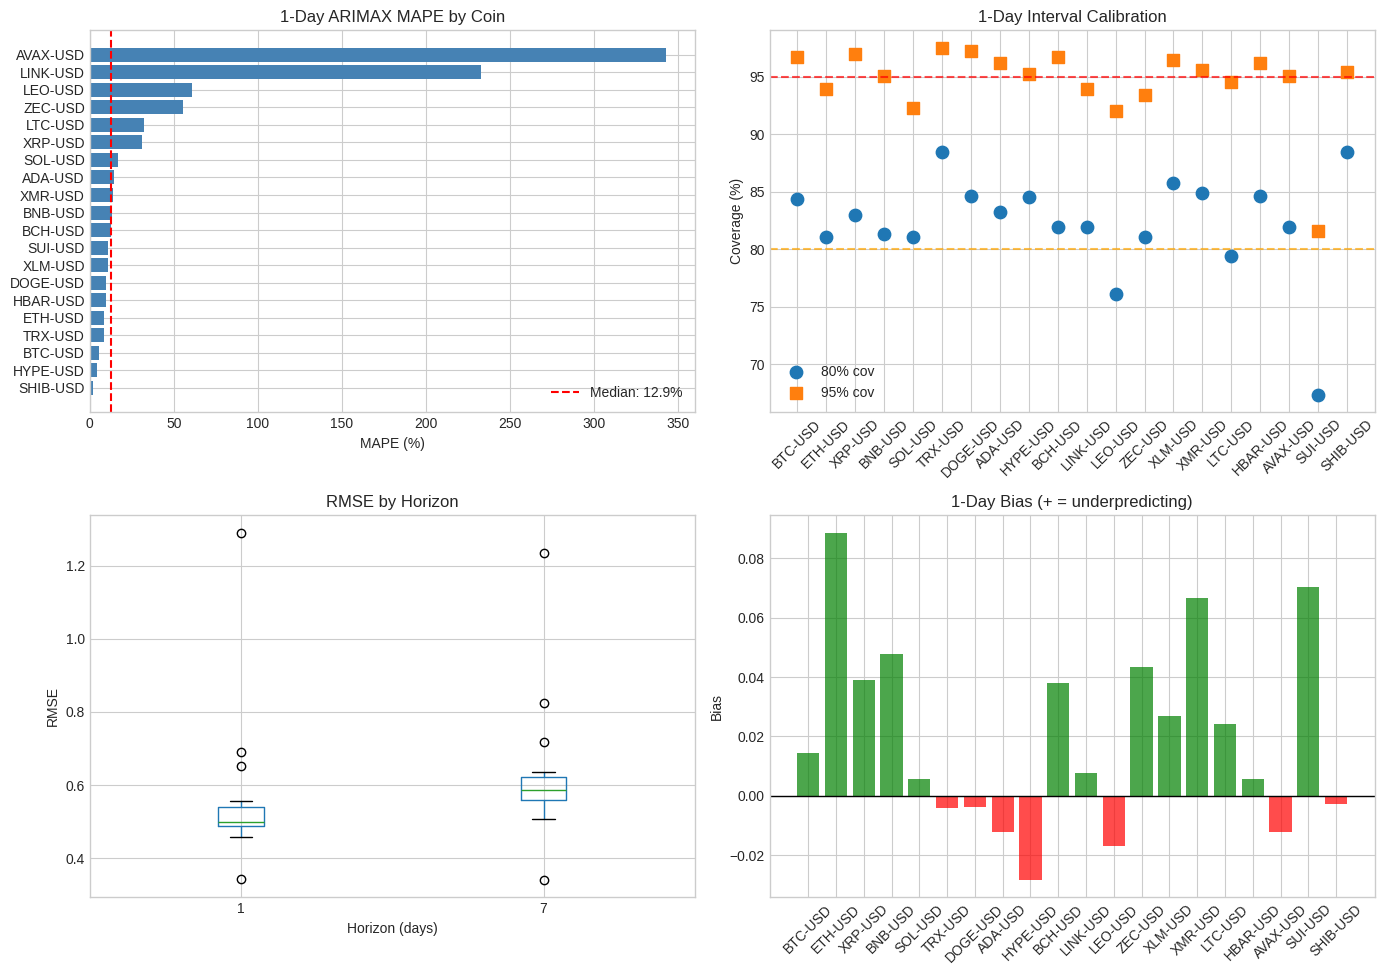

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAPE by coin
ax1 = axes[0, 0]
h1 = metrics_df[metrics_df['horizon'] == 1].sort_values('mape')
ax1.barh(h1['ticker'], h1['mape'], color='steelblue')
ax1.set_xlabel('MAPE (%)')
ax1.set_title('1-Day ARIMAX MAPE by Coin')
ax1.axvline(h1['mape'].median(), color='red', linestyle='--', label=f"Median: {h1['mape'].median():.1f}%")
ax1.legend()

# Coverage calibration
ax2 = axes[0, 1]
h1 = metrics_df[metrics_df['horizon'] == 1]
ax2.scatter(h1['ticker'], h1['coverage_80'], s=80, marker='o', label='80% cov')
ax2.scatter(h1['ticker'], h1['coverage_95'], s=80, marker='s', label='95% cov')
ax2.axhline(80, color='orange', linestyle='--', alpha=0.7)
ax2.axhline(95, color='red', linestyle='--', alpha=0.7)
ax2.set_ylabel('Coverage (%)')
ax2.set_title('1-Day Interval Calibration')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# RMSE boxplot
ax3 = axes[1, 0]
metrics_df.boxplot(column='rmse', by='horizon', ax=ax3)
ax3.set_title('RMSE by Horizon')
ax3.set_xlabel('Horizon (days)')
ax3.set_ylabel('RMSE')
plt.suptitle('')

# Bias by coin
ax4 = axes[1, 1]
h1 = metrics_df[metrics_df['horizon'] == 1]
colors = ['green' if b > 0 else 'red' for b in h1['bias']]
ax4.bar(h1['ticker'], h1['bias'], color=colors, alpha=0.7)
ax4.axhline(0, color='black', lw=1)
ax4.set_ylabel('Bias')
ax4.set_title('1-Day Bias (+ = underpredicting)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}arimax_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "=" * 70)
print("ARIMAX MODEL SUMMARY")
print("=" * 70)

for h in CONFIG['horizons']:
    h_data = metrics_df[metrics_df['horizon'] == h]
    print(f"\n{h}-Day Horizon:")
    print(f"  Coins: {len(h_data)}")
    print(f"  Predictions: {h_data['n'].sum():,}")
    print(f"  MAPE: {h_data['mape'].mean():.1f}% (median: {h_data['mape'].median():.1f}%)")
    print(f"  80% coverage: {h_data['coverage_80'].mean():.1f}%")
    print(f"  95% coverage: {h_data['coverage_95'].mean():.1f}%")
    print(f"  Bias: {h_data['bias'].mean():.4f}")

print("\n" + "-" * 70)
print("Features used:")
for f in FEATURES:
    print(f"  - {f}")
print("-" * 70)


ARIMAX MODEL SUMMARY

1-Day Horizon:
  Coins: 20
  Predictions: 6,871
  MAPE: 44.8% (median: 12.9%)
  80% coverage: 82.3%
  95% coverage: 94.6%
  Bias: 0.0199

7-Day Horizon:
  Coins: 20
  Predictions: 6,752
  MAPE: 42.4% (median: 15.1%)
  80% coverage: 99.2%
  95% coverage: 99.9%
  Bias: 0.0254

----------------------------------------------------------------------
Features used:
  - vol_ratio
  - vol_spike
  - return_1d
  - return_7d
  - range_ratio
  - btc_return_1d
  - btc_return_7d
  - btc_range_ratio
  - btc_dominance
  - fng
  - fng_ma7
  - fng_extreme_fear
  - fng_extreme_greed
  - is_weekend
----------------------------------------------------------------------


In [ ]:
from google.colab import files
import shutil

shutil.make_archive('/content/arimax_results', 'zip', CONFIG['output_dir'])
files.download('/content/arimax_results.zip')

print("\nDownload complete!")
print("Contents:")
print("  - arimax_metrics.csv (model performance)")
print("  - arimax_features.csv (feature data)")
print("  - [ticker]_arimax.png (per-coin plots)")
print("  - arimax_summary.png (overall summary)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download complete!
Contents:
  - arimax_metrics.csv (model performance)
  - arimax_features.csv (feature data)
  - [ticker]_arimax.png (per-coin plots)
  - arimax_summary.png (overall summary)
